# Threshold Analysis — Fraud Detection

This notebook analyzes how different fraud probability thresholds affect fraud detection results.

The goal is to connect machine learning predictions with business decisions such as manual review, missed fraud, and risk exposure.

In [25]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Random Forest Predictions

Load the Random Forest fraud probabilities saved from the model training notebook.

In [26]:
# Define path to saved Random Forest predictions
PREDICTIONS_PATH = "../reports/random_forest_predictions.csv"

# Load prediction data
threshold_df = pd.read_csv(PREDICTIONS_PATH)

# Display dataset shape
print("Threshold input shape:")
print(threshold_df.shape)

# Display first rows
display(threshold_df.head())

Threshold input shape:
(56746, 33)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,y_true,fraud_probability,prediction_050
0,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,11.50,0,0.0,0
1,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.94,0,0.0,0
2,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,91.28,0,0.0,0
3,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,228.00,0,0.0,0
4,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,1.41,0,0.0,0


**Result:** The threshold input dataset contains **56,746 test transactions** and **33 columns**.

It includes transaction features, true fraud labels, Random Forest fraud probabilities, and default model predictions.

This dataset connects the trained ML model with the threshold analysis part of the simulator.

## 3. Prepare Variables

Separate true labels, fraud probabilities, and transaction amounts for threshold calculations.

In [27]:
# Extract true fraud labels
y_true = threshold_df["y_true"]

# Extract predicted fraud probabilities
fraud_probability = threshold_df["fraud_probability"]

# Extract transaction amounts
amounts = threshold_df["Amount"]

# Display basic checks
print("Number of transactions:", len(y_true))
print("Number of real fraud transactions:", y_true.sum())
print("Average fraud probability:", round(fraud_probability.mean(), 4))

Number of transactions: 56746
Number of real fraud transactions: 95
Average fraud probability: 0.0014


**Result:** The test set contains **56,746 transactions**, including **95 real fraud transactions**.

The average predicted fraud probability is **0.0014**, which reflects the strong class imbalance in the dataset.

This confirms that fraud is rare and the fraud threshold must be selected carefully.

## 4. Evaluate Multiple Fraud Thresholds

Test different fraud thresholds and calculate model and business metrics for each threshold.

In [28]:
# Create threshold values from 0.05 to 0.95
thresholds = np.arange(0.05, 1.00, 0.05)

# Create an empty list to store threshold results
threshold_results = []

# Loop through each threshold
for threshold in thresholds:
    
    # Convert probabilities into class predictions using current threshold
    y_pred_threshold = (fraud_probability >= threshold).astype(int)
    
    # Calculate precision, recall, and F1-score
    precision = precision_score(y_true, y_pred_threshold, zero_division=0)
    recall = recall_score(y_true, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_true, y_pred_threshold, zero_division=0)
    
    # Calculate confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    
    # Calculate manual review rate
    manual_review_rate = y_pred_threshold.mean()
    
    # Calculate missed fraud amount
    missed_fraud_mask = (y_true == 1) & (y_pred_threshold == 0)
    missed_fraud_amount = amounts[missed_fraud_mask].sum()
    
    # Save threshold result
    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "manual_review_rate": manual_review_rate,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "missed_fraud_amount": missed_fraud_amount
    })

# Convert results into DataFrame
threshold_results_df = pd.DataFrame(threshold_results)

# Display threshold results
display(threshold_results_df)

,threshold,precision,recall,f1_score,manual_review_rate,true_positives,false_positives,false_negatives,true_negatives,missed_fraud_amount
0,0.05,0.715596,0.821053,0.764706,0.001921,78,31,17,56620,3781.79
1,0.10,0.873563,0.800000,0.835165,0.001533,76,11,19,56640,3786.58
2,0.15,0.903614,0.789474,0.842697,0.001463,75,8,20,56643,3790.34
3,0.20,0.913580,0.778947,0.840909,0.001427,74,7,21,56644,3790.34
4,0.25,0.946667,0.747368,0.835294,0.001322,71,4,24,56647,4051.53
5,0.30,0.958904,0.736842,0.833333,0.001286,70,3,25,56648,5861.21
6,0.35,0.958333,0.726316,0.826347,0.001269,69,3,26,56648,5873.52
7,0.40,0.958333,0.726316,0.826347,0.001269,69,3,26,56648,5873.52
8,0.45,0.971429,0.715789,0.824242,0.001234,68,2,27,56649,5874.20
9,0.50,0.971014,0.705263,0.817073,0.001216,67,2,28,56649,6135.42


**Result:** Multiple fraud thresholds were tested from **0.05 to 0.95**.

For each threshold, the analysis calculated precision, recall, F1-score, manual review rate, false positives, false negatives, and missed fraud amount.

This table shows how different fraud filter settings affect both fraud detection and operational workload.

## 5. Visualize Threshold Trade-Off

Visualize how precision, recall, F1-score, and manual review rate change across thresholds.

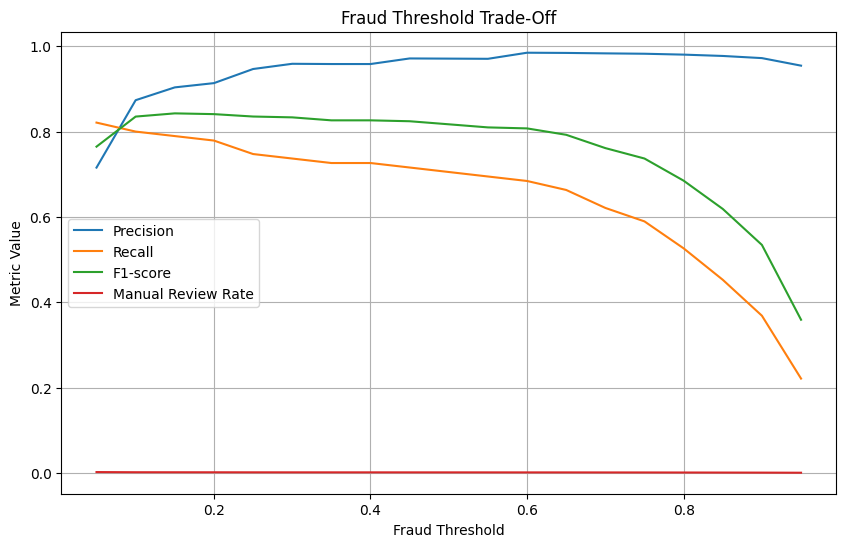

In [29]:
# Create line plot for threshold metrics
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    label="F1-score"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["manual_review_rate"],
    label="Manual Review Rate"
)

plt.title("Fraud Threshold Trade-Off")
plt.xlabel("Fraud Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)

plt.show()

**Result:** The plot shows the trade-off between precision, recall, F1-score, and manual review rate.

As the threshold increases, precision generally becomes higher, but recall becomes lower.

This means stricter fraud filter settings reduce false alarms but increase the risk of missing fraud.

## 6. Missed Fraud Amount Analysis

Analyze how much fraudulent transaction value is missed at different thresholds.

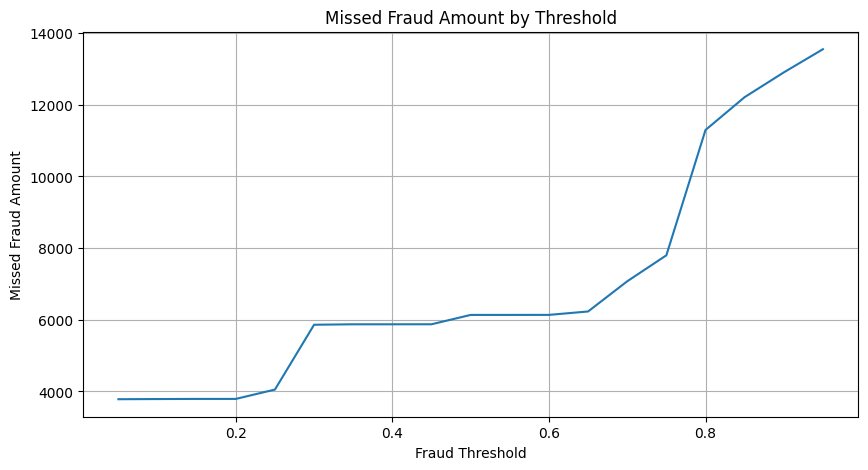

In [30]:
# Plot missed fraud amount by threshold
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["missed_fraud_amount"]
)

plt.title("Missed Fraud Amount by Threshold")
plt.xlabel("Fraud Threshold")
plt.ylabel("Missed Fraud Amount")

plt.grid(True)

plt.show()

**Result:** The missed fraud amount increases when the fraud threshold becomes higher.

This means that higher thresholds reduce manual review workload but allow more fraud value to pass undetected.

This is important because **Risk Exposure (EUR)** is one of the main simulator KPIs.

## 7. Recommended Threshold

Select a practical threshold based on business constraints.

For this project, the rule is:

- manual review rate must stay below 5%
- within that limit, maximize fraud recall

In [31]:
# Define maximum acceptable manual review rate
MAX_MANUAL_REVIEW_RATE = 0.05

# Filter thresholds that keep manual review rate below the limit
candidate_thresholds = threshold_results_df[
    threshold_results_df["manual_review_rate"] <= MAX_MANUAL_REVIEW_RATE
]

# Select threshold with the highest recall among candidates
recommended_threshold = candidate_thresholds.sort_values(
    by="recall",
    ascending=False
).head(1)

# Display recommended threshold
display(recommended_threshold)

,threshold,precision,recall,f1_score,manual_review_rate,true_positives,false_positives,false_negatives,true_negatives,missed_fraud_amount
0,0.05,0.715596,0.821053,0.764706,0.001921,78,31,17,56620,3781.79


**Result:** The recommended threshold is **0.05**.

At this threshold, the model detects **78 out of 95 fraud transactions** and misses **17 fraud transactions**.

The manual review rate is only **0.19%**, which is below the 5% business constraint.

This threshold gives a practical balance between fraud detection and operational workload.

## 8. Business Interpretation

Threshold analysis connects the ML model to business decisions.

A lower fraud threshold catches more fraud but sends more transactions to manual review.

A higher fraud threshold reduces manual review workload but may miss more fraud.

The recommended threshold balances fraud detection and operational workload.

In [32]:
# Extract recommended threshold values
best_row = recommended_threshold.iloc[0]

# Print business interpretation
print("Recommended threshold:", best_row["threshold"])
print("Precision:", round(best_row["precision"], 4))
print("Recall:", round(best_row["recall"], 4))
print("F1-score:", round(best_row["f1_score"], 4))
print("Manual review rate:", round(best_row["manual_review_rate"] * 100, 2), "%")
print("False positives:", int(best_row["false_positives"]))
print("False negatives:", int(best_row["false_negatives"]))
print("Missed fraud amount:", round(best_row["missed_fraud_amount"], 2))

Recommended threshold: 0.05
Precision: 0.7156
Recall: 0.8211
F1-score: 0.7647
Manual review rate: 0.19 %
False positives: 31
False negatives: 17
Missed fraud amount: 3781.79


**Result:** At threshold **0.05**, the model achieves:

- precision: **0.7156**
- recall: **0.8211**
- F1-score: **0.7647**
- manual review rate: **0.19%**
- false positives: **31**
- false negatives: **17**
- missed fraud amount: **3,781.79**

This means the fraud filter catches most fraud cases while keeping manual review workload very low.

This supports the main goal of balancing speed, security, manual reviews, and risk exposure.

## 9. Save Threshold Results

Save the threshold analysis table for reporting and README documentation.

In [33]:
# Define output path for threshold results
THRESHOLD_RESULTS_PATH = "../reports/threshold_analysis_results.csv"

# Save threshold results
threshold_results_df.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False
)

# Confirm saved file
print(f"Threshold analysis results saved to: {THRESHOLD_RESULTS_PATH}")

Threshold analysis results saved to: ../reports/threshold_analysis_results.csv


## 10. Threshold Analysis Summary

This notebook shows how Random Forest fraud probabilities can be converted into business decisions.

The threshold controls the trade-off between:

- fraud detection
- manual review workload
- false positives
- false negatives
- missed fraud amount

This connects the machine learning fraud detection model with the original simulator idea.

The next step is to connect these threshold insights to the Streamlit simulator and final presentation.